# OFDM Channel Sounding

Authors: Meles Gebreyesus Weldegebriel and Neal Patwari
Version: Mar 2026. Version 0.1.

This code assumes that someone has done the following before you run this tutorial.
1. Generate a "channel sounding OFDM packet" (of all pilot channels) for transmission over SDRs
2. The packet is then transmitted over the air in POWDER using Shout using the given instructions.

In this notebook, we're going to run only the receiver, and estimate and plot the channel frequency response (CFR) and channel impulse response (CIR).

This code  allows you to:
1. Load the received data from file.
2. Synchronize to the OFDM packet.
3. Take the FFT of each symbol to get the subchannel (complex) values
4. Use the known transmitted complex subchannel pilot values to compute the channel gain in magnitude and phase
5. Plot the CFR and CIR in different ways: over the `repetitions` symbols,  over frequency (the pilot subchannels), and on average over all repetitions.

In [91]:
import os
import json
import math
import numpy as np
import matplotlib.pyplot as plt
import h5py
import datetime
import scipy.io
import scipy.signal as signal
from itertools import chain
from scipy.signal import correlate, correlation_lags, fftconvolve

## 1. Load the received data from file.

In [130]:
load_from_gtihub = False

# # Load in files from the github repo for this tutorial.
if load_from_gtihub:
  user = "npatwari"
  repo = "ch-sounding-ofdm-packet"
  # remove local directory if it already exists
  if os.path.isdir(repo):
    !rm -rf {repo}
else:
  # user must upload the zip file to the working directory.
  datestr = "03-10-2026_15-23-32"
  zipfile = "/content/Shout_meas_" + datestr + ".zip"
  !unzip -o {zipfile}
  data_dir = os.path.splitext(zipfile)[0]
  print("data_dir = " + data_dir)


# !git clone https://github.com/{user}/{repo}.git

Archive:  /content/Shout_meas_03-10-2026_15-23-32.zip
 extracting: Shout_meas_03-10-2026_15-23-32/log  
  inflating: Shout_meas_03-10-2026_15-23-32/save_iq_w_tx_file.json  
  inflating: Shout_meas_03-10-2026_15-23-32/measurements.hdf5  
data_dir = /content/Shout_meas_03-10-2026_15-23-32


In [93]:
## Load in settings about the all-pilot OFDM symbol
# User must upload the npz file
datestamp_OFDMdata = "10-03-26"


# Load the npz file and extract the pilot values and parameters
npz_filename = "pilot-info-" + datestamp_OFDMdata + ".npz"
print("Loading from " + npz_filename)
with np.load(npz_filename) as temp:
  OFDM_vals = temp["data"]
  norm_ofdm_time = temp["norm_ofdm_time"]
  print("len(norm_ofdm_time): " + str(len(norm_ofdm_time)))

  eps = 1e-5
  pilotCarriers = np.where(np.abs(OFDM_vals) > eps)
  print(pilotCarriers)
  pilotValues = OFDM_vals[pilotCarriers]
  FFT_size = len(OFDM_vals)
  pilots = len(pilotValues)
  OFDM_size = FFT_size

  # in the future, load this from temp['repetitions']
  repetitions = 50

Loading from pilot-info-10-03-26.npz
len(norm_ofdm_time): 64
(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 36, 37, 38, 39, 40, 41,
       42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58,
       59, 60, 61, 62, 63]),)


Our simple OFDM packet structure is simply many repetitions of the same all-pilot OFDM symbol.


Here, we load the rx signal from a previously conducted OTA experiment file.

In [94]:
def get_time_string(timestamp):
    '''
    Helper function to get data and time from timestamp
    INPUT: timestamp
    OUTPUT: data and time. Example: 01-04-2023, 19:50:27
    '''
    date_time = datetime.datetime.fromtimestamp(int(timestamp))
    return date_time.strftime("%m-%d-%Y, %H:%M:%S")

def JsonLoad(folder, json_file):
    '''
    Load parameters from the saved json file
    INPUT
    ----
        folder: path to the measurement folder. Example: "SHOUT/Results/Shout_meas_01-04-2023_18-50-26"
        json_file: the json file with all the specifications. Example: '/save_iq_w_tx_gold.json'
    OUTPUT
    ----
        samps_per_chip: samples per chip
        wotxrepeat: number of repeating IQ sample collection w/o transmission. Used as an input to
        traverse_dataset() func
        rxrate: sampling rate at the receiver side
    '''
    config_file = folder+'/'+json_file
    config_dict = json.load(open(config_file))[0]
    nsamps = config_dict['nsamps']
    rxrate = config_dict['rxrate']
    rxfreq = config_dict['rxfreq']
    wotxrepeat = config_dict['wotxrepeat']
    rxrepeat = config_dict['rxrepeat']
    txnodes = config_dict['txclients']
    rxnodes = config_dict['rxclients']

    return rxrepeat, rxrate, txnodes, rxnodes

def traverse_dataset(meas_folder):
    '''
    Load data from hdf5 format measurement file
    INPUT
    ----
        meas_folder: path to the measurement folder. Example: "SHOUT/Results/Shout_meas_01-04-2023_18-50-26"
    OUTPUT
    ----
        data: Collected IQ samples w/ transmission. It is indexed by the transmitter name
        noise: Collected IQ samples w/o transmission. It is indexed by the transmitter name
        txrxloc: transmitter and receiver names
    '''
    data = {}
    noise = {}
    txrxloc = {}

    dataset = h5py.File(meas_folder + '/measurements.hdf5', "r") #meas_folder
    print("Dataset meta data:", list(dataset.attrs.items()))
    for cmd in dataset.keys():
        print("Command:", cmd)
        if cmd == 'saveiq':
            cmd_time = list(dataset[cmd].keys())[0]
            print("  Timestamp:", get_time_string(cmd_time))
            print("  Command meta data:", list(dataset[cmd][cmd_time].attrs.items()))
            for rx_gain in dataset[cmd][cmd_time].keys():
                print("   RX gain:", rx_gain)
                for rx in dataset[cmd][cmd_time][rx_gain].keys():
                    print("     RX:", rx)
                    print("       Measurement items:", list(dataset[cmd][cmd_time][rx_gain][rx].keys()))
        elif cmd == 'saveiq_w_tx':
            cmd_time = list(dataset[cmd].keys())[0]
            print("  Timestamp:", get_time_string(cmd_time))
            print("  Command meta data:", list(dataset[cmd][cmd_time].attrs.items()))
            for tx in dataset[cmd][cmd_time].keys():
                print("   TX:", tx)

                if tx == 'wo_tx':
                    for rx_gain in dataset[cmd][cmd_time][tx].keys():
                        print("       RX gain:", rx_gain)
                        #print(dataset[cmd][cmd_time][tx][rx_gain].keys())
                        for rx in dataset[cmd][cmd_time][tx][rx_gain].keys():
                            print("         RX:", rx)
                            #print("           Measurement items:", list(dataset[cmd][cmd_time][tx][rx_gain][rx].keys()))
                            repeat = np.shape(dataset[cmd][cmd_time][tx][rx_gain][rx]['rxsamples'])[0]
                            print("         repeat", repeat)

                            samplesNotx =  dataset[cmd][cmd_time][tx][rx_gain][rx]['rxsamples'][:repeat, :]
                            namelist = rx.split('-')
                            noise[namelist[1]] = samplesNotx
                else:
                    for tx_gain in dataset[cmd][cmd_time][tx].keys():
                        print("     TX gain:", tx_gain)
                        for rx_gain in dataset[cmd][cmd_time][tx][tx_gain].keys():
                            print("       RX gain:", rx_gain)
                            #print(dataset[cmd][cmd_time][tx][tx_gain][rx_gain].keys())
                            for rx in dataset[cmd][cmd_time][tx][tx_gain][rx_gain].keys():
                                repeat = np.shape(dataset[cmd][cmd_time][tx][tx_gain][rx_gain][rx]['rxsamples'])[0]
                                print("         RX:", rx, "; samples shape", np.shape(dataset[cmd][cmd_time][tx][tx_gain][rx_gain][rx]['rxsamples']))
                                #print("         Measurement items:", list(dataset[cmd][cmd_time][tx][tx_gain][rx_gain][rx].keys()))
                                # print("         rxloc", (dataset[cmd][cmd_time][tx][tx_gain][rx_gain][rx]['rxloc'][0]))
                                # peak avg check
                                txrxloc.setdefault(tx, []).extend([rx]*repeat)
                                rxsamples = dataset[cmd][cmd_time][tx][tx_gain][rx_gain][rx]['rxsamples'][:repeat, :]
                                data.setdefault(tx, []).append(np.array(rxsamples))

        else:
            print('Unsupported command: ', cmd)

    return data, noise, txrxloc

In [95]:
rx_data, noise, txrxloc = traverse_dataset(data_dir)

jsonfile = "save_iq_w_tx_file.json"
rxrepeat, samp_rate, txlocs, rxlocs = JsonLoad(data_dir, jsonfile)

print("rxrepeat: " + str(rxrepeat))
print("samp_rate: " + str(samp_rate))
print("txlocs: " + str(txlocs))
print("rxlocs: " + str(rxlocs))


Dataset meta data: [('shout_version', '495923e')]
Command: saveiq_w_tx
  Timestamp: 03-10-2026, 21:23:34
  Command meta data: [('cmd', 'save_iq_w_tx'), ('nsamps', np.int64(8192)), ('rxfreq', np.float64(3385000000.0)), ('rxgain', np.float64(30.0)), ('rxrate', np.float64(500000.0)), ('rxrepeat', np.int64(4)), ('rxwait_max', np.int64(2000)), ('rxwait_min', np.int64(50)), ('rxwait_random', np.True_), ('rxwait_res', 'ms'), ('start_time', np.float64(1773177820.0)), ('sync', np.True_), ('timeout', np.int64(30)), ('timezone', 'US/Mountain'), ('txfile', '/local/repository/shout/signal_library/channel-sounding-OFDM-packet-10-03-26.iq'), ('txfreq', np.float64(3385000000.0)), ('txgain', np.float64(27.0)), ('txrate', np.float64(500000.0)), ('txwait', np.int64(3)), ('use_lo_offset', np.True_), ('wotxrepeat', np.int64(4))]
   TX: cbrssdr1-bes-comp
     TX gain: 27.0
       RX gain: 30.0
         RX: cbrssdr1-browning-comp ; samples shape (4, 8192)
         RX: cbrssdr1-fm-comp ; samples shape (4, 819

Plot the frequency domain representation of the received signal to "see" that the signal was transmitted and received correctly.

cbrssdr1-bes-comp


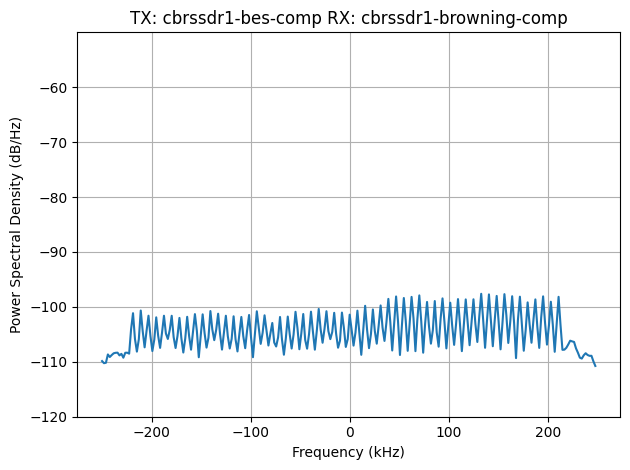

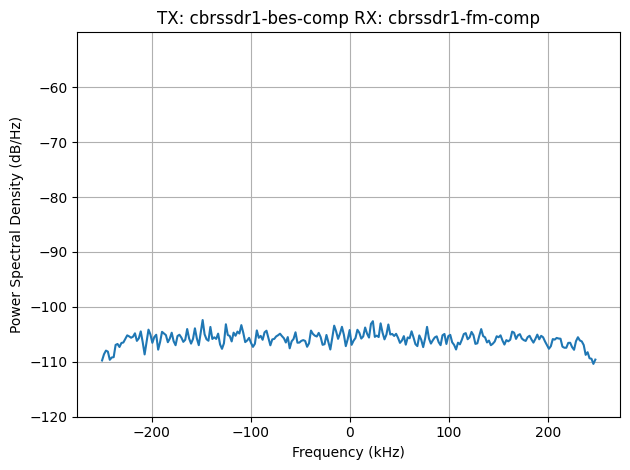

cbrssdr1-browning-comp


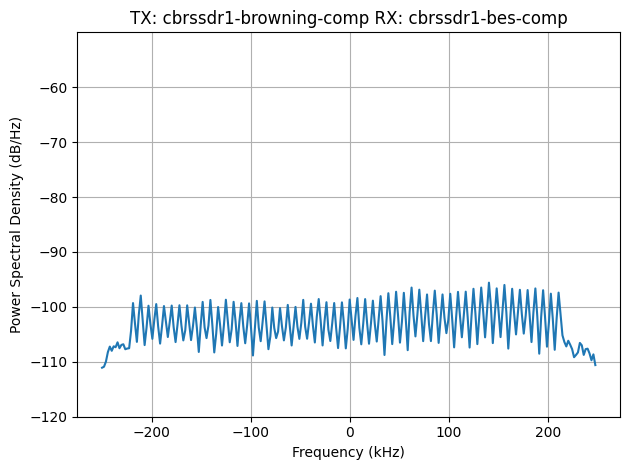

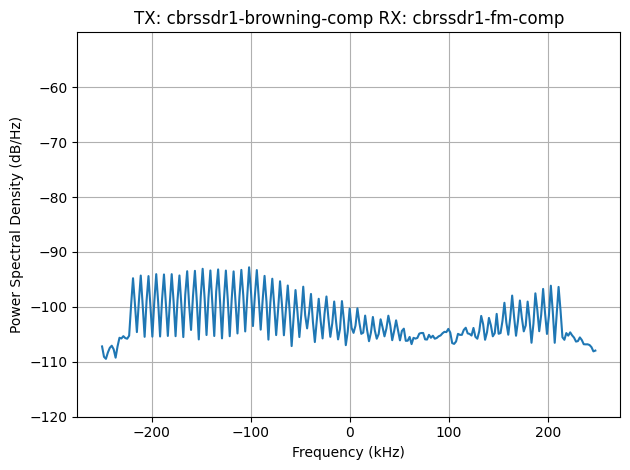

cbrssdr1-fm-comp


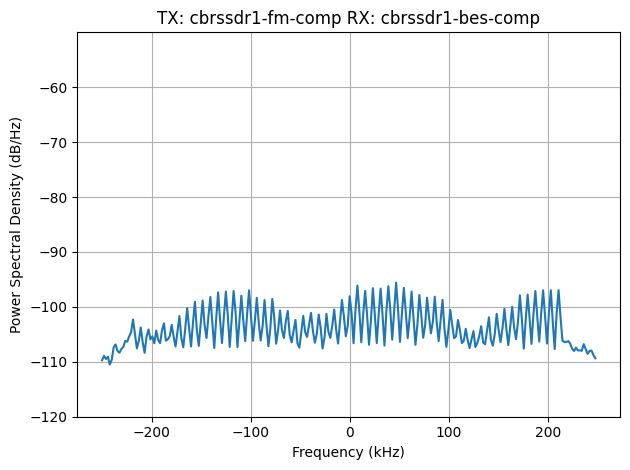

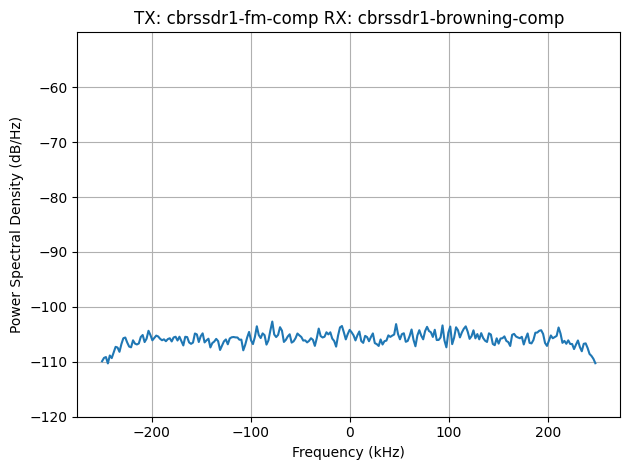

cbrssdr1-honors-comp


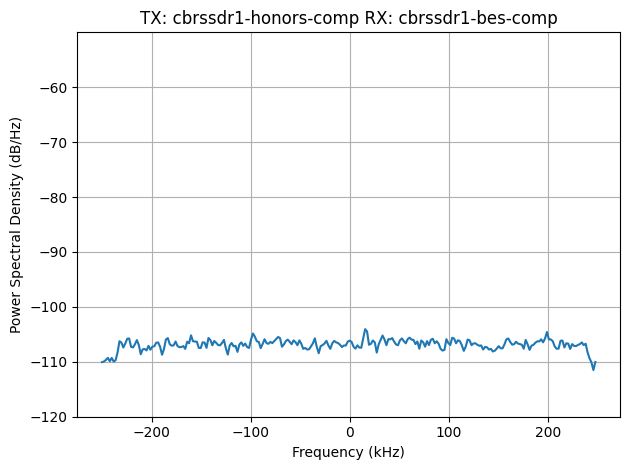

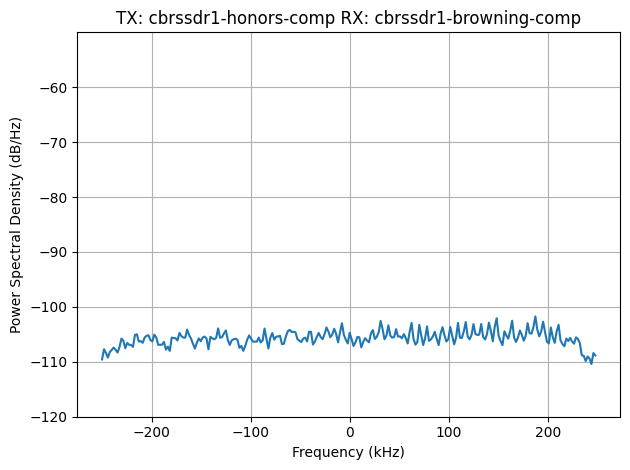

cbrssdr1-hospital-comp


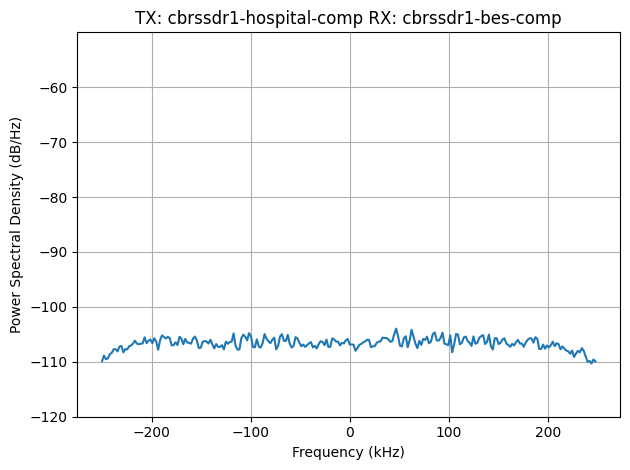

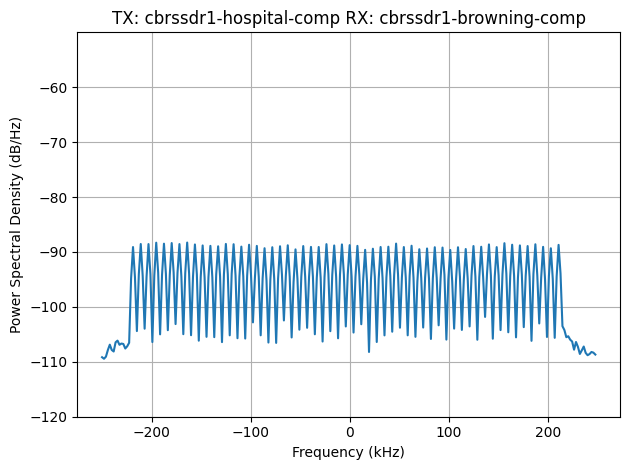

cbrssdr1-ustar-comp


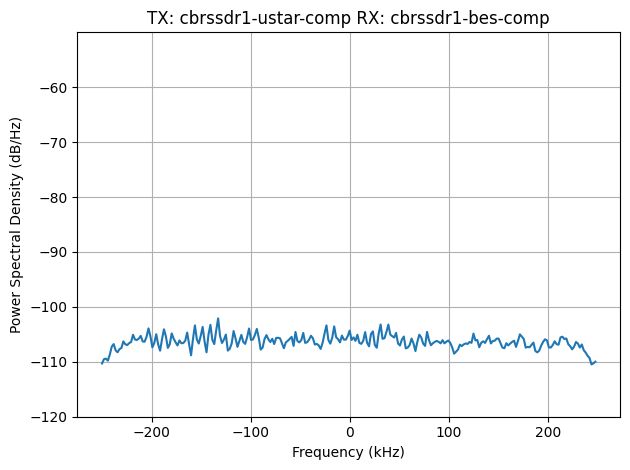

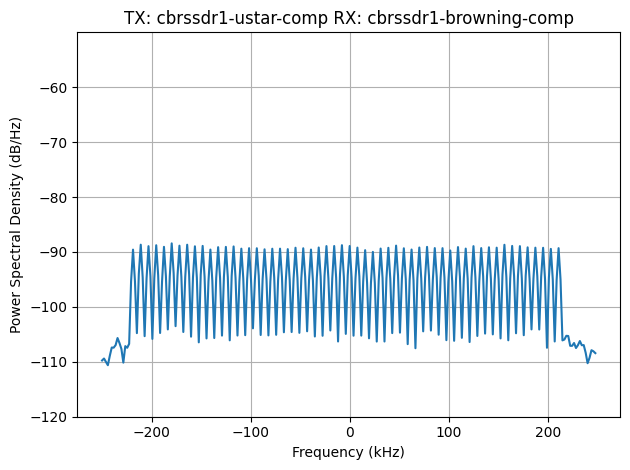

In [96]:
def plotOnePSDForEachLink(rx_data, txrxloc, samp_rate, repeats, repNum):
    for txname in rx_data:
        print(txname)
        for i in range(0, len(rx_data[txname]), repeats):
            plt.figure()
            # This code arbitrarily picks the 0 rep to plot.
            plt.psd(rx_data[txname][i][repNum], Fs = samp_rate/1000)

            ylimits = [-120, -50]
            plt.ylim(ylimits)
            plt.yticks(range(ylimits[0], ylimits[1],10))

            plt.grid('on')
            plt.title('TX: {} RX: {}'.format(txname, txrxloc[txname][i]))
            plt.xlabel('Frequency (kHz)')
            plt.tight_layout()
            plt.show()


# Plot all links, but just the data from the 0th repetition
# To change the repetition number, add repNum=n for n in the range 0 to the
# total number of repetitions -1.
plotOnePSDForEachLink(rx_data, txrxloc, samp_rate, repeats=4, repNum=0)

In [123]:
# Pick one received signal to work on
txloc = 'cbrssdr1-browning-comp' # eg.,
rxloc = 'cbrssdr1-bes-comp' # eg., 'cbrssdr1-meb-comp'
repNum = 1 # eg., 0

rx_data[txloc] = np.vstack(rx_data[txloc])
rxloc_arr = np.array(txrxloc[txloc])
rx0 = rx_data[txloc][rxloc_arr==rxloc][repNum]
print('\nLink: {} to {}. Repetition Num {}.'.format(txloc, rxloc, repNum))
rx0.shape


Link: cbrssdr1-browning-comp to cbrssdr1-bes-comp. Repetition Num 1.


(8192,)

2. Synchronize to the OFDM packet.

This code uses frequency domain convolution. Since the full convolution is computed with a single product, it is faster for our case.

Each received symbol will be highly correlated with the known symbol. There are `repetitions` symbols. Thus, we'll see a period of about 1k samples that are noise only, followed by `repetitions` correlation peaks. We want to find the **first** peak in the set of `repetitions` peaks. This procedure:
1. first finds a "noise only" period,
2. then finds the first peak after the end of the noise only period.

This first peak after the noise-only peak becomes the first index of our OFDM packet.

Median Correlation: 0.00050664257
Detected preamble at sample index 2059


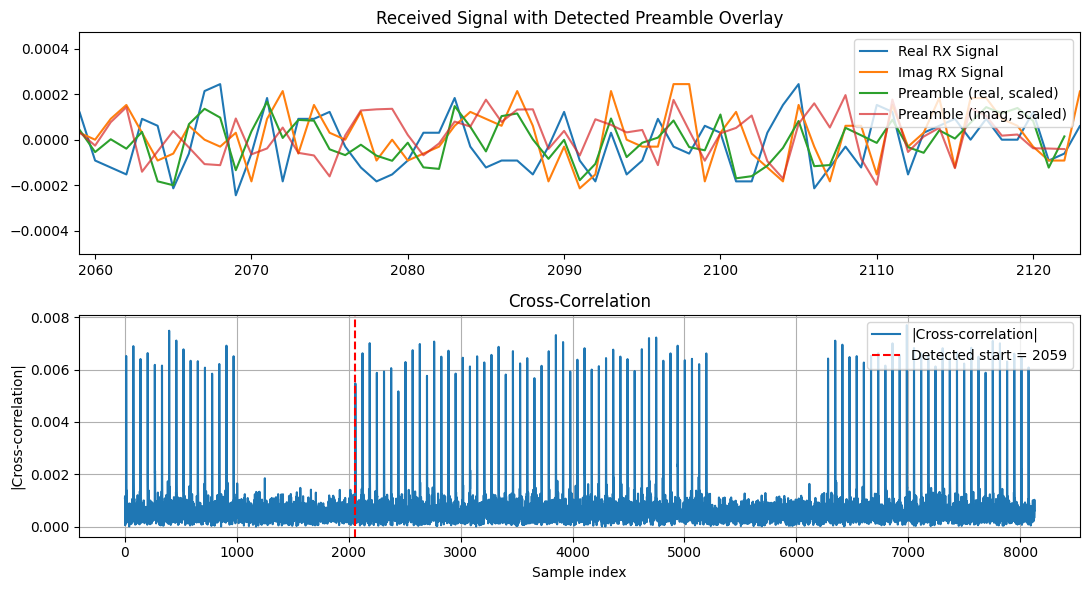

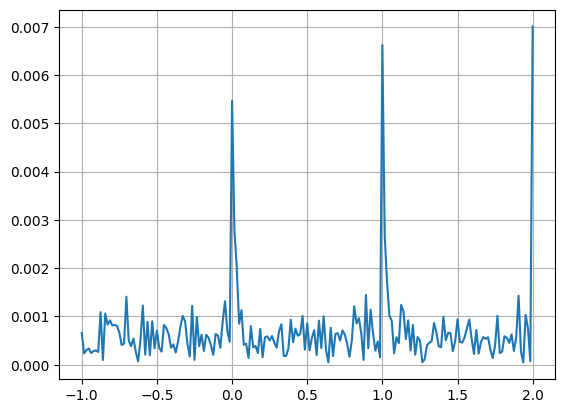

In [124]:
def cross_correlation_max(rx0, preamble, preamble_scale=0.001):
    """
    Cross-correlate rx0 with a known preamble and plot:
      - RX real/imag with the detected preamble overlaid at the detected start index
      - Correlation magnitude (or NCC) vs. sample index (no negative lags)
    """

    rx0 = np.asarray(rx0, dtype=np.complex64)
    preamble = np.asarray(preamble, dtype=np.complex64)

    # --- Complex matched filter correlation ---
    kernel = np.conj(preamble[::-1])
    xcorr_out = signal.fftconvolve(rx0, kernel, mode='valid')  # valid mode → only non-negative shifts
    metric = np.abs(xcorr_out)
    median_corr = np.median(metric)
    print("Median Correlation: " + str(median_corr))

    # Return the index of the first peak of the correlation output
    # after a period of more than RR samples of noise. This is because when
    # we create the signal, we add 1024 samples of zeros before the packet.
    RR = 512
    delta = RR//16
    lag_index = 0
    max_index = len(rx0) - RR
    threshold = 4*median_corr
    noise_only = (np.max(metric[lag_index:lag_index+RR]) < threshold)
    lag_index += delta
    while (not noise_only) and lag_index < max_index:
        if np.max(metric[lag_index:lag_index+RR]) < threshold:
            noise_only = True
        lag_index += delta

    while noise_only and lag_index < max_index:
        if np.max(metric[lag_index:lag_index+RR]) > threshold:
            noise_only = False
            preamble_start = np.argmax(metric[lag_index:lag_index+RR]) + lag_index
        lag_index += delta

    # Output the results, the preamble_start index and some plots to help us
    # make sure that the procedure worked correctly.
    print(f"Detected preamble at sample index {preamble_start}")
    # --- Plot the output so the user can validate that it is working ---
    fig, axes = plt.subplots(2, 1, figsize=(11, 6))
    # Top: RX signal with overlaid preamble
    axes[0].plot(np.real(rx0), label='Real RX Signal')
    axes[0].plot(np.imag(rx0), label='Imag RX Signal')
    overlay_x = np.arange(preamble_start, preamble_start + len(preamble))
    overlay_p = preamble * preamble_scale
    axes[0].plot(overlay_x, np.real(overlay_p), label='Preamble (real, scaled)')
    axes[0].plot(overlay_x, np.imag(overlay_p), label='Preamble (imag, scaled)', alpha=0.7)
    axes[0].set_xlim(preamble_start, preamble_start + len(preamble))
    axes[0].set_title("Received Signal with Detected Preamble Overlay")
    axes[0].legend(loc='upper right')
    # Bottom: correlation metric vs. index
    axes[1].plot(metric, label="|Cross-correlation|")
    axes[1].axvline(preamble_start, linestyle='--', color='r', label=f'Detected start = {preamble_start}')
    axes[1].set_xlabel("Sample index")
    axes[1].set_ylabel("|Cross-correlation|")
    axes[1].legend(loc='upper right')
    axes[1].set_title(f"Cross-Correlation")
    axes[1].grid(True)
    plt.tight_layout()
    plt.show()

    # Plot metric within 100 samples around preamble_start
    plt.figure()
    plt.plot(np.arange(-64, 2*64+1)/64, metric[preamble_start-64:preamble_start+2*64+1])
    plt.grid(True)
    plt.show()
    return preamble_start


preamble_start = cross_correlation_max(rx0, norm_ofdm_time, preamble_scale=0.0002)

We can estimate the complex (magnitude, angle) gain that each pilot subcarrier gets multiplied by, because we know what the original complex amplitude that was sent in the pilot subcarrier (`pilotValues`). This code calls those pilot subcarrier gains as `Hp`. We consider this full channel estimation because all subcarriers, except for the guard bands, are pilot channels.

This section implements estimating the channel gain by dividing the measured (received) pilot value by the pilot value that was known to be sent.

In [125]:
def Channel_Estimation(signal, pilotValues):
    """
    Estimate the per-subcarrier channel H[k] for ONE OFDM symbol using pilots only.
    Strategy:
      1. Pull out the complex amplitude in the pilot subcarriers.
      2. Divide by Xp, the known pilot symbol value that was transmitted.
      3. Perform interpolation to estimate the channel at the data subcarriers.
         (Do linear interpolation on the log magnitude and on phase, separately)

    """
    eps = 1e-13  # small number to prevent divide-by-zero / log(0)

    # Pull out the complex amplitude in the pilot subcarriers.
    # Call your output `Yp`
    ### YOUR CODE HERE
    Yp = signal[pilotCarriers]

    # Divide by Xp, the known pilot symbol value that was transmitted
    # Make sure you don't divide by zero!  Call the output `Hp`
    ### YOUR CODE HERE
    Xp = pilotValues
    Hp = Yp / (Xp + eps)

    return Hp

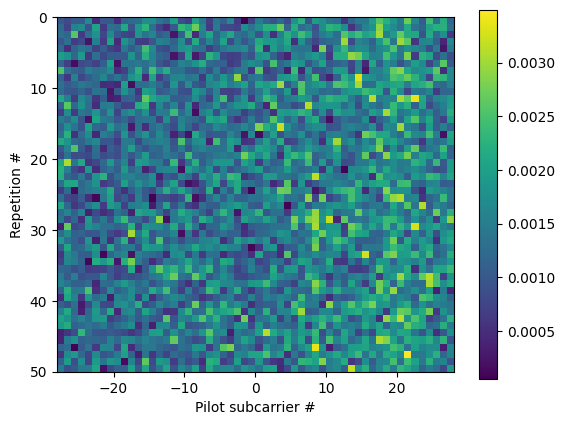

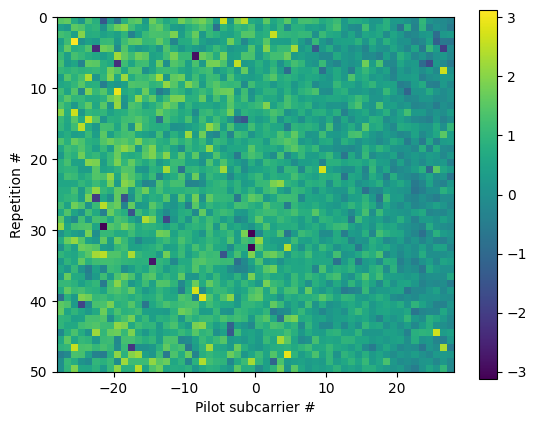

In [137]:
# Calculate the start index of the DATA part of the packet. Then copy `mess_length`
# samples, starting from that start index, into `data_signal`.
data_start = preamble_start
packet_len = FFT_size * repetitions
data_signal = rx0[data_start: data_start + packet_len]

# Process each symbol (which is `FFT_size` samples).
# Remember `FFT_size` is the total symbol length including the part that will
# have an FFT taken, and the cyclic prefix which will be dropped.
H_est = np.zeros((repetitions, pilots)) + 1j*np.zeros((repetitions, pilots))
for i in range(len(data_signal)//(FFT_size)):

    # Pick out the next `FFT_size` of samples from `data_signal`,
    # and call it `data_cp`.
    symbol_i = data_signal[i*(FFT_size):(i+1)*(FFT_size)]
    OFDM_freq = np.fft.fft(symbol_i, n=FFT_size)

    # Estimate the complex channel gain coefficients, using the pilot subcarriers.
    temp = Channel_Estimation(OFDM_freq, pilotValues) # estimate the channel

    # do the reverse of the FFT shift, because they arrive in temp out of order.
    H_est[i, 0:pilots//2] = temp[pilots//2:]
    H_est[i, pilots//2:] = temp[0:pilots//2]

# Make the filename include the experiment datetime, the TX, RX, and repnum.
plotname_str = datestr + "_" + txloc + "_" + rxloc + "_rep" + str(repNum)

# Plot the 2d H_est as a 3d plot
plt.figure()
plt.imshow(np.abs(H_est), interpolation='None', extent=[-pilots//2,pilots//2,repetitions,0])
plt.xlabel("Pilot subcarrier #")
plt.ylabel("Repetition #")
plt.colorbar()
plt.savefig("H_est_abs_" + plotname_str + ".pdf")

# Plot the 2d H_est as a 3d plot
plt.figure()
plt.imshow(np.angle(H_est), interpolation='None', extent=[-pilots//2,pilots//2,repetitions,0])
plt.xlabel("Pilot subcarrier #")
plt.ylabel("Repetition #")
plt.colorbar()
plt.savefig("H_est_angle_" + plotname_str + ".pdf")


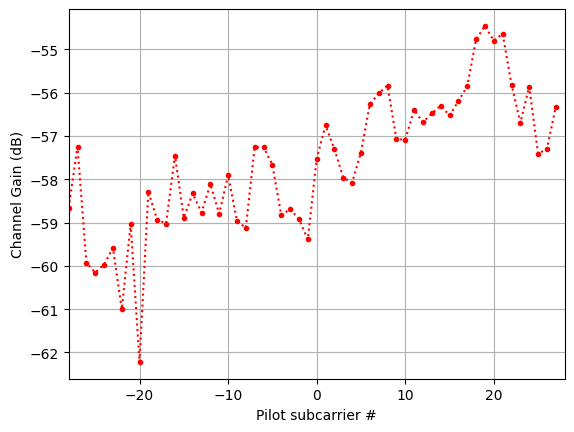

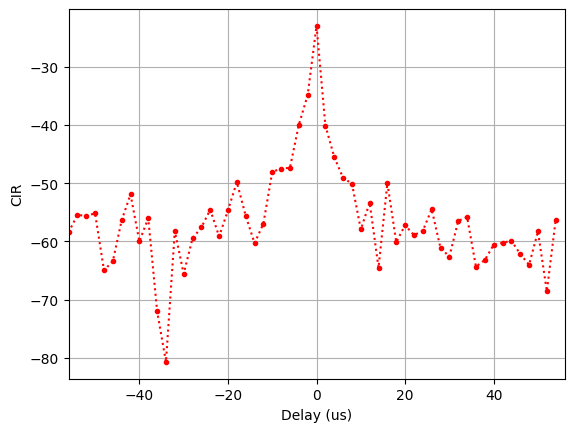

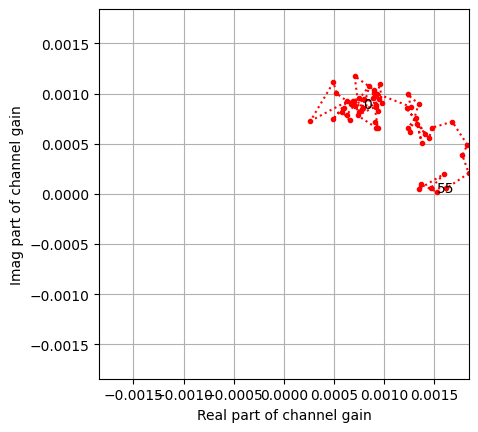

In [138]:
avg_H = np.mean(H_est, axis=0)
plt.figure()
plt.plot(range(-pilots//2,pilots//2), 20*np.log10(np.abs(avg_H)), 'r.:')
plt.xlabel("Pilot subcarrier #")
plt.xlim(-pilots//2,pilots//2)
plt.ylabel("Channel Gain (dB)")
plt.grid(True)
plt.savefig("H_avg_dB_" + plotname_str + ".pdf")

CIR = np.fft.fftshift(np.fft.fft(avg_H))
bandwidth = .500 # MHz
delta_t = 1/bandwidth # microseconds
tau = np.arange(-pilots//2,pilots//2) * delta_t
plt.figure()
plt.plot(tau, 20*np.log10(np.abs(CIR)), 'r.:')
plt.xlabel("Delay (us)")
plt.xlim((delta_t*(-pilots//2),delta_t*(pilots//2)))
plt.ylabel("CIR")
plt.grid(True)
plt.savefig("CIR_dB_" + plotname_str + ".pdf")

plt.figure()
maxlim = max(max(np.real(avg_H)), max(np.imag(avg_H)))
plt.plot(np.real(avg_H), np.imag(avg_H), 'r.:')
plt.text(np.real(avg_H[0]), np.imag(avg_H[0]), '0')
plt.text(np.real(avg_H[-1]), np.imag(avg_H[-1]), str(pilots-1))
plt.xlim(-maxlim,maxlim)
plt.ylim(-maxlim,maxlim)
plt.gca().set_aspect('equal')
plt.xlabel("Real part of channel gain")
plt.ylabel("Imag part of channel gain")
plt.grid(True)
plt.savefig("H_polar_" + plotname_str + ".pdf")
